In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams["font.family"] = "Arial"

In [2]:
meta = pd.read_csv("../../data/fay_meta_diets.csv", index_col=0)

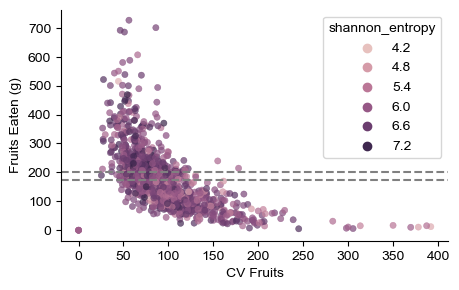

In [3]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3))
sns.scatterplot(
    data=meta,
    x="CV_fruits_fg_eaten",
    y="fruits_fg_eaten",
    hue="shannon_entropy",
    alpha=0.7,
    s=20,
    edgecolor=None,
)
ax.set_xlabel("CV Fruits")
ax.set_ylabel("Fruits Eaten (g)")
plt.axhline(y=175, color="gray", linestyle="--")
plt.axhline(y=200, color="gray", linestyle="--")
sns.despine()
fig.savefig(
    "../../figures/cv_mean_validation/cv_fruits_vs_fruits_eaten.png",
    dpi=300,
    bbox_inches="tight",
)

CV_fruits_fg_eaten_quintile  above_mean_shannon
0                            True                  10
                             False                  8
1                            True                  11
                             False                  7
2                            False                  9
                             True                   9
3                            False                 11
                             True                   7
4                            False                 11
                             True                   7
Name: above_mean_shannon, dtype: int64


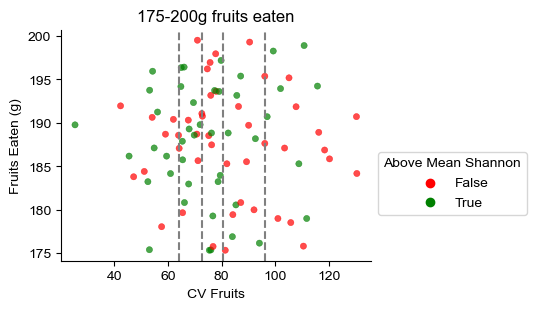

In [4]:
v = meta.copy()
v = v[(v["fruits_fg_eaten"] > 175) & (v["fruits_fg_eaten"] < 200)]
v["CV_fruits_fg_eaten_quintile"] = pd.qcut(v["CV_fruits_fg_eaten"], 5, labels=False)
v["above_mean_shannon"] = v["shannon_entropy"] > meta["shannon_entropy"].mean()

print(v.groupby(["CV_fruits_fg_eaten_quintile"])["above_mean_shannon"].value_counts())

##########################
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 3))
sns.scatterplot(
    data=v,
    x="CV_fruits_fg_eaten",
    y="fruits_fg_eaten",
    hue="above_mean_shannon",
    palette={True: "green", False: "red"},
    alpha=0.7,
    s=20,
    edgecolor=None,
)
quintiles = v["CV_fruits_fg_eaten"].quantile([0.2, 0.4, 0.6, 0.8])
for q in quintiles:
    plt.axvline(x=q, color="gray", linestyle="--")
plt.title("175-200g fruits eaten")
ax.set_xlabel("CV Fruits")
ax.set_ylabel("Fruits Eaten (g)")
ax.legend(title="Above Mean Shannon", bbox_to_anchor=(1, 0.5))
sns.despine()

fig.savefig(
    "../../figures/cv_mean_validation/cv_fruits_vs_fruits_eaten_175_200g.png",
    dpi=300,
    bbox_inches="tight",
)

In [5]:
v["CV_fruits_fg_eaten_quintile"] = pd.qcut(v["CV_fruits_fg_eaten"], 5, labels=False)
v["above_mean_shannon"] = v["shannon_entropy"] > meta["shannon_entropy"].mean()

v.groupby(["CV_fruits_fg_eaten_quintile"])["above_mean_shannon"].value_counts()

CV_fruits_fg_eaten_quintile  above_mean_shannon
0                            True                  10
                             False                  8
1                            True                  11
                             False                  7
2                            False                  9
                             True                   9
3                            False                 11
                             True                   7
4                            False                 11
                             True                   7
Name: above_mean_shannon, dtype: int64

### Ploting CV Fruits on each fruits_eaten chunks wherein the tendency is to have more CV Fruits in the higher quintiles


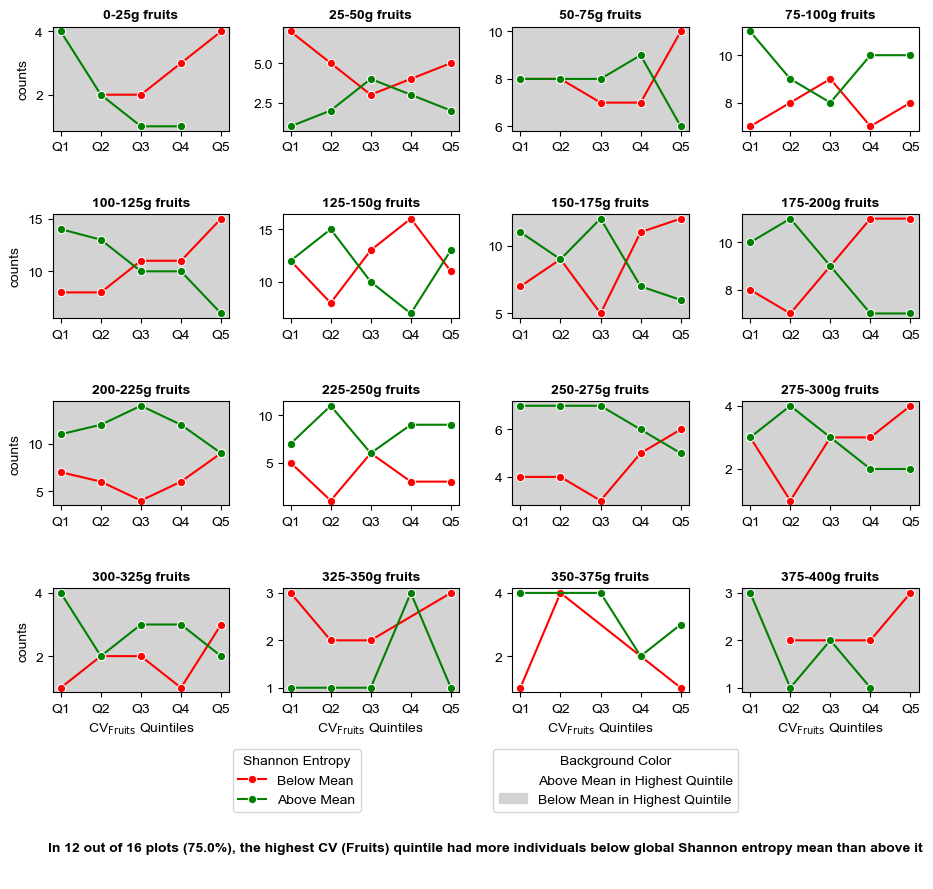

In [6]:
def create_cv_fruits_quintiles_subplot(data, i, diff, ax, show_ylabel=False):
    # Filter data for current range
    mask = (data["fruits_fg_eaten"] > i) & (data["fruits_fg_eaten"] < i + diff)
    subset = data[mask].copy()

    # Calculate quintiles and binary shannon entropy
    subset["CV_fruits_fg_eaten_quintile"] = pd.qcut(
        subset["CV_fruits_fg_eaten"], 5, labels=False
    )
    subset["above_mean_shannon"] = (
        subset["shannon_entropy"] > data["shannon_entropy"].mean()
    )

    # Get counts
    counts = (
        subset.groupby(["CV_fruits_fg_eaten_quintile", "above_mean_shannon"])
        .size()
        .reset_index(name="counts")
    )

    # Create plot
    line_plot = sns.lineplot(
        data=counts,
        x="CV_fruits_fg_eaten_quintile",
        y="counts",
        hue="above_mean_shannon",
        marker="o",
        ax=ax,
        legend=False,
        palette={True: "green", False: "red"},
    )

    # Set x-axis labels to Q1, Q2, etc.
    ax.set_xticks(range(5))
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])

    # Only show y label if specified
    if not show_ylabel:
        ax.set_ylabel("")

    # Set title
    ax.set_title(f"{i}-{i+diff}g fruits", fontsize=10, fontweight="bold")

    # Set background color based on highest quintile comparison
    highest_quintile = counts[counts["CV_fruits_fg_eaten_quintile"] == 4]
    true_count = highest_quintile[highest_quintile["above_mean_shannon"] == True][
        "counts"
    ].values
    false_count = highest_quintile[highest_quintile["above_mean_shannon"] == False][
        "counts"
    ].values

    true_val = true_count[0] if len(true_count) > 0 else 0
    false_val = false_count[0] if len(false_count) > 0 else 0

    is_below_mean = true_val <= false_val
    ax.set_facecolor("lightgrey" if is_below_mean else "white")

    return line_plot, is_below_mean


# Setup parameters
diff = 25
num_cols = 4
fruits_eaten_range = 400
num_rows = int(fruits_eaten_range / diff // num_cols)

# Create figure and subplots with extra space at bottom for legends and annotation
fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(
    nrows=num_rows + 2, ncols=num_cols, height_ratios=[1] * num_rows + [0.1, 0.1]
)

# Create subplot axes
axes = []
for row in range(num_rows):
    row_axes = []
    for col in range(num_cols):
        ax = fig.add_subplot(gs[row, col])
        row_axes.append(ax)
    axes.append(row_axes)

# Convert to numpy array for easier indexing
axes = np.array(axes)

# Track below mean counts
below_mean_count = 0
total_plots = 0

# Create subplots
lines = []
for idx, i in enumerate(range(0, fruits_eaten_range, diff)):
    row, col = divmod(idx, num_cols)
    show_ylabel = col == 0

    line_plot, is_below_mean = create_cv_fruits_quintiles_subplot(
        meta,
        i,
        diff,
        axes[row, col],
        show_ylabel=show_ylabel,
    )

    # Track counts
    below_mean_count += int(is_below_mean)
    total_plots += 1

    axes[row, col].set_xlabel(
        r"CV$_{\mathrm{Fruits}}$ Quintiles" if row == num_rows - 1 else ""
    )

    if idx == 0:
        lines = line_plot.get_lines()

# Create legends at the bottom
bottom_gs = gs[-2, :]
bottom_ax = fig.add_subplot(bottom_gs)
bottom_ax.axis("off")

# Create Shannon Entropy legend
leg1 = bottom_ax.legend(
    lines[:2],
    ["Below Mean", "Above Mean"],
    title="Shannon Entropy",
    loc="center left",
    bbox_to_anchor=(0.2, 0.5),
)
bottom_ax.add_artist(leg1)

# Create Background Color legend
import matplotlib.patches as mpatches

white_patch = mpatches.Patch(color="white", label="Above Mean in Highest Quintile")
grey_patch = mpatches.Patch(color="lightgrey", label="Below Mean in Highest Quintile")
leg2 = bottom_ax.legend(
    handles=[white_patch, grey_patch],
    title="Background Color",
    loc="center right",
    bbox_to_anchor=(0.8, 0.5),
)

# Add annotation in the very bottom
annotation_gs = gs[-1, :]
annotation_ax = fig.add_subplot(annotation_gs)
annotation_ax.axis("off")

# Calculate percentage
below_mean_percentage = (below_mean_count / total_plots) * 100

annotation_text = (
    f"In {below_mean_count} out of {total_plots} plots ({below_mean_percentage:.1f}%), "
    f"the highest CV (Fruits) quintile had more individuals below global Shannon entropy mean than above it"
)

annotation_ax.text(
    0.5, 3, annotation_text, ha="center", va="center", fontsize=10, fontweight="bold"
)

plt.tight_layout()

fig.savefig(
    "../../figures/cv_mean_validation/cv_fruits_quintiles_mean_validation.png",
    dpi=300,
    bbox_inches="tight",
)

### Plotting the reverse of the above plot


In [7]:
# diff = 25

# num_plots = (200) / diff
# fig, ax = plt.subplots(nrows=int(num_plots // 2), ncols=2, figsize=(8, num_plots))

# for e, i in enumerate(range(25, 200, diff)):
#     v = meta.copy()
#     v = v[(v["CV_fruits_fg_eaten"] > i) & (v["CV_fruits_fg_eaten"] < i + diff)]

#     v["fruits_fg_eaten_quintile"] = pd.qcut(v["fruits_fg_eaten"], 5, labels=False)
#     v["above_mean_shannon"] = v["shannon_entropy"] > meta["shannon_entropy"].mean()

#     counts = (
#         v.groupby(["fruits_fg_eaten_quintile", "above_mean_shannon"])
#         .size()
#         .reset_index(name="counts")
#     )

#     if e == len(range(0, 400, diff)) - 2:
#         show_legend = True
#     else:
#         show_legend = False

#     sns.lineplot(
#         data=counts,
#         x="fruits_fg_eaten_quintile",
#         y="counts",
#         hue="above_mean_shannon",
#         marker="o",
#         ax=ax[e // 2, e % 2],
#         legend=show_legend,
#         palette={True: "green", False: "red"},
#     )
#     ax[e // 2, e % 2].set_title(f"{i}-{i+diff} CV fruits eaten")
#     if e == len(range(0, 400, diff)) - 1:
#         ax[e // 2, e % 2].legend(title="Above Mean Shannon", bbox_to_anchor=(1, 0.5))

#     if e // 2 == int(num_plots // 2) - 1:
#         ax[e // 2, e % 2].set_xlabel("fruits_fg_eaten_quintile")
#     else:
#         ax[e // 2, e % 2].set_xlabel("")

#     true_count = counts[
#         (counts["fruits_fg_eaten_quintile"] == 4)
#         & (counts["above_mean_shannon"] == True)
#     ]["counts"].values
#     false_count = counts[
#         (counts["fruits_fg_eaten_quintile"] == 4)
#         & (counts["above_mean_shannon"] == False)
#     ]["counts"].values

#     true_count = true_count[0] if len(true_count) > 0 else 0
#     false_count = false_count[0] if len(false_count) > 0 else 0

#     if true_count - false_count > 0:
#         ax[e // 2, e % 2].set_facecolor("white")
#     else:
#         ax[e // 2, e % 2].set_facecolor("lightgrey")


# plt.tight_layout()
# plt.show()

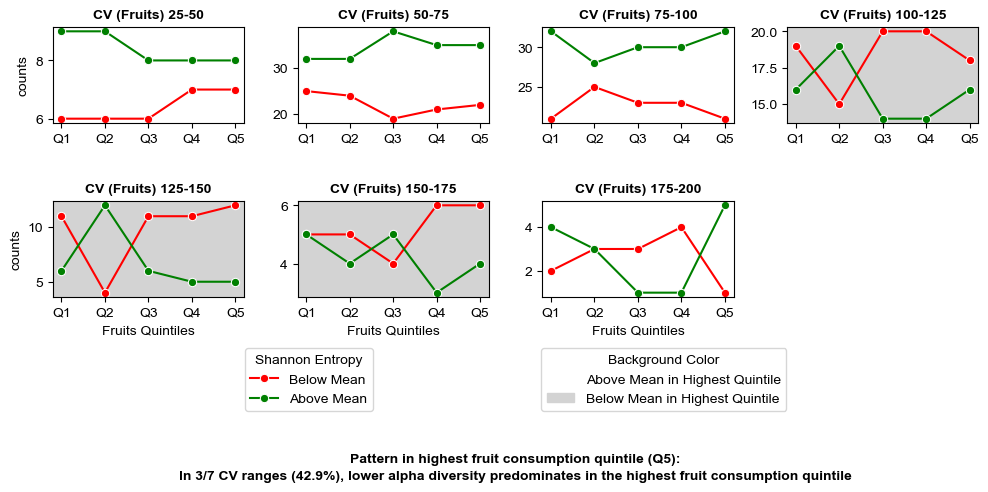

In [8]:
def create_fruits_quintiles_subplot_reverse(data, i, diff, ax, show_ylabel=False):
    # Filter data for current range
    mask = (data["CV_fruits_fg_eaten"] > i) & (data["CV_fruits_fg_eaten"] < i + diff)
    subset = data[mask].copy()

    # Calculate quintiles and binary shannon entropy
    subset["fruits_fg_eaten_quintile"] = pd.qcut(
        subset["fruits_fg_eaten"], 5, labels=False
    )
    subset["above_mean_shannon"] = (
        subset["shannon_entropy"] > data["shannon_entropy"].mean()
    )

    # Get counts
    counts = (
        subset.groupby(["fruits_fg_eaten_quintile", "above_mean_shannon"])
        .size()
        .reset_index(name="counts")
    )

    # Create plot
    line_plot = sns.lineplot(
        data=counts,
        x="fruits_fg_eaten_quintile",
        y="counts",
        hue="above_mean_shannon",
        marker="o",
        ax=ax,
        legend=False,
        palette={True: "green", False: "red"},
    )

    # Set x-axis labels to Q1, Q2, etc.
    ax.set_xticks(range(5))
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])

    # Only show y label if specified
    if not show_ylabel:
        ax.set_ylabel("")

    # Set title
    ax.set_title(f"CV (Fruits) {i}-{i+diff}", fontsize=10, fontweight="bold")

    # Set background color based on highest quintile comparison
    highest_quintile = counts[counts["fruits_fg_eaten_quintile"] == 4]
    true_count = highest_quintile[highest_quintile["above_mean_shannon"] == True][
        "counts"
    ].values
    false_count = highest_quintile[highest_quintile["above_mean_shannon"] == False][
        "counts"
    ].values

    true_val = true_count[0] if len(true_count) > 0 else 0
    false_val = false_count[0] if len(false_count) > 0 else 0

    is_below_mean = true_val <= false_val
    ax.set_facecolor("lightgrey" if is_below_mean else "white")

    return line_plot, is_below_mean


# Setup parameters
diff = 25
num_cols = 4

cv_fruits_eaten_range = 200

# Calculate number of rows based on actual number of plots
range_length = len(range(25, cv_fruits_eaten_range, diff))
num_rows = (range_length + num_cols - 1) // num_cols

# Create figure and subplots with extra space at bottom for legends and annotation
fig = plt.figure(figsize=(10, 5))  # Adjusted for 2 columns
gs = fig.add_gridspec(
    nrows=num_rows + 2, ncols=num_cols, height_ratios=[1] * num_rows + [0.1, 0.1]
)

# Create subplot axes
axes = []
for row in range(num_rows):
    row_axes = []
    for col in range(num_cols):
        ax = fig.add_subplot(gs[row, col])
        row_axes.append(ax)
    axes.append(row_axes)

# Convert to numpy array for easier indexing
axes = np.array(axes)

# Track below mean counts
below_mean_count = 0
total_plots = 0

# Create subplots
lines = []
total_iterations = len(range(25, cv_fruits_eaten_range, diff))

for idx, i in enumerate(range(25, cv_fruits_eaten_range, diff)):
    # Calculate position
    row, col = divmod(idx, num_cols)

    # Skip if this would be an empty panel
    if idx >= total_iterations:
        continue

    show_ylabel = col == 0

    line_plot, is_below_mean = create_fruits_quintiles_subplot_reverse(
        meta,
        i,
        diff,
        axes[row, col],
        show_ylabel=show_ylabel,
    )

    # Track counts
    below_mean_count += int(is_below_mean)
    total_plots += 1

    axes[row, col].set_xlabel(r"Fruits Quintiles" if row == num_rows - 1 else "")

    if idx == 0:
        lines = line_plot.get_lines()

# Remove empty subplot if it exists
if total_iterations % num_cols != 0:
    fig.delaxes(axes[num_rows - 1][num_cols - 1])


# Create legends at the bottom
bottom_gs = gs[-2, :]
bottom_ax = fig.add_subplot(bottom_gs)
bottom_ax.axis("off")

# Create Shannon Entropy legend
leg1 = bottom_ax.legend(
    lines[:2],
    ["Below Mean", "Above Mean"],
    title="Shannon Entropy",
    loc="center left",
    bbox_to_anchor=(0.2, 0.5),
)
bottom_ax.add_artist(leg1)

# Create Background Color legend
import matplotlib.patches as mpatches

white_patch = mpatches.Patch(color="white", label="Above Mean in Highest Quintile")
grey_patch = mpatches.Patch(color="lightgrey", label="Below Mean in Highest Quintile")
leg2 = bottom_ax.legend(
    handles=[white_patch, grey_patch],
    title="Background Color",
    loc="center right",
    bbox_to_anchor=(0.8, 0.5),
)

# Add annotation in the very bottom
annotation_gs = gs[-1, :]
annotation_ax = fig.add_subplot(annotation_gs)
annotation_ax.axis("off")

# Calculate percentage
below_mean_percentage = (below_mean_count / total_plots) * 100

annotation_text = (
    "Pattern in highest fruit consumption quintile (Q5):\n"
    f"In {below_mean_count}/{total_plots} CV ranges ({below_mean_percentage:.1f}%), "
    "lower alpha diversity predominates in the highest fruit consumption quintile"
)

annotation_ax.text(
    0.5,
    0.5,
    annotation_text,
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    linespacing=1.5,
)

plt.tight_layout()

fig.savefig(
    "../../figures/cv_mean_validation/cv_fruits_quintiles_mean_validation_reverse.png",
    dpi=300,
    bbox_inches="tight",
)